My goal here is to get the spin-glass method working. The specifics of this method are coming from reichardtStatisticalMechanicsCommunity2006.

In order to compute our update rules we need some methods to compute the terms we will need.

# 1. Hamiltonian

I'm not sure that we are acutally going to use this in our method as we only care about the change in energy.
But it is nice to have.

We should be able to compute it a number of ways, here we define our functions for adhesion and cohesion as well.

In [11]:
import numpy as np

In [12]:
def hamiltonian(A, sigma, gamma=1.0, P=None):
    """
    Compute the Potts-model Hamiltonian for a graph partition.

    The Hamiltonian is

        H = -sum_{i,j} (A_ij - gamma P_ij) delta(sigma_i, sigma_j),

    where A is the adjacency matrix, P is a null-model expectation,
    and sigma assigns each node to a community. By default, P is
    constructed from the node strengths so that the Hamiltonian is
    equivalent to the standard modularity objective up to an overall
    constant.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node. `sigma[i]` is the state
        of node `i`.
    gamma : float, optional
        Resolution parameter controlling the relative weight of the
        null-model term. Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix specifying the expected edge weight between
        nodes. If None, uses

            P_ij = k_i k_j / sum_k k_k,

        where k_i is the strength of node i.

    Returns
    -------
    float
        Value of the Potts Hamiltonian for the specified partition.

    Notes
    -----
    Only pairs of nodes belonging to the same community contribute to
    the Hamiltonian. Diagonal terms are excluded explicitly.

    For an undirected graph, both `(i, j)` and `(j, i)` appear in the
    sum, so each internal edge contributes twice.
    """
    # typecast
    A = np.asarray(A, float)
    sigma = np.asarray(sigma)
    
    if P is None: # by default use model that gives modularity
        k = A.sum(axis=1)
        P = np.outer(k, k) / k.sum()
    
    # Compute coupling in potts model
    J = A - gamma * P
    
    # delta function
    same = sigma[:, None] == sigma[None, :] 
    
    # make sure i \neq j
    np.fill_diagonal(same, False)
    
    return -np.sum(J * same)

def _blocks(A, sigma, gamma=1.0, P=None):
    """
    Aggregate the graph and null-model matrices by community.

    For each pair of communities `(r, s)`, computes

        D_rs = sum_{i in r, j in s} (A_ij - gamma P_ij).

    Thus, `D` gives the realized-minus-expected coupling between every
    pair of communities.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Diagonal entries are ignored and
        set to zero.
    sigma : array_like, shape (n,)
        Community label assigned to each node. The ordering must match
        the rows and columns of `A`.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, uses

            P_ij = k_i k_j / sum_k k_k,

        where k_i is the node strength.

        The null-model matrix is rescaled so that its total weight
        matches the total weight of `A`, and its diagonal is set to
        zero.

    Returns
    -------
    labels : ndarray
        Sorted array of unique community labels appearing in `sigma`.
    D : ndarray, shape (q, q)
        Community-level coupling matrix, where `q` is the number of
        communities. Element `(r, s)` is

            D_rs = M_rs - gamma E_rs,

        with `M_rs` the total realized edge weight and `E_rs` the total
        expected weight between communities `r` and `s`.

    Notes
    -----
    The aggregation is performed using a one-hot community membership
    matrix `S`, such that

        M = S.T @ A @ S
        E = S.T @ P @ S.

    For an undirected graph, off-diagonal blocks `(r, s)` and `(s, r)`
    contain the same edge weight, while diagonal blocks count each
    internal edge twice.
    """
    A = np.array(A, float)
    np.fill_diagonal(A, 0) # remove self loops 
    
    if P is None: # by default use model that gives modularity
        k = A.sum(axis=1)
        P = np.outer(k, k) / k.sum()
        
    # NOTE this is not needed for minimisation, just makes our values match!
    P = np.array(P, float)
    np.fill_diagonal(P, 0)
    P *= A.sum() / P.sum()      # enforce sum_{i<j} p_ij = m

    P = np.array(P, float)
    np.fill_diagonal(P, 0) # no i = j terms in the expectation

    labels, idx = np.unique(np.asarray(sigma), return_inverse=True)
    S = np.zeros((len(idx), len(labels)))
    S[np.arange(len(idx)), idx] = 1.0 # one-hot membership

    M = S.T @ A @ S # M_rs = sum_{i in r, j in s} A_ij
    E = S.T @ P @ S # same for the null model
    return labels, M - gamma * E

def cohesion(A, sigma, gamma=1.0, P=None):
    """
    Compute the cohesion of each community.

    The cohesion of community `s` is defined as

        c_ss = m_ss - gamma E_ss,

    where `m_ss` is the total realized edge weight within community `s`
    and `E_ss` is the corresponding expected weight under the null model.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    labels : ndarray
        Unique community labels, in the order returned by `np.unique`.
    c : ndarray, shape (q,)
        Cohesion of each community, where `q` is the number of
        communities.

    Notes
    -----
    For an undirected graph, the diagonal block of `_blocks` counts
    every internal edge twice. The returned cohesion therefore contains
    a factor of 1/2:

        c_s = 1/2 D_ss.

    Consequently, `c_s` counts each internal edge once.
    """
    labels, D = _blocks(A, sigma, gamma, P)
    return labels, 0.5 * np.diag(D)           # diagonal counts each internal pair twice

def adhesion(A, sigma, gamma=1.0, P=None):
    """
    Compute the adhesion between every pair of communities.

    For communities `r` and `s`, the adhesion is

        a_rs = m_rs - gamma E_rs,

    where `m_rs` is the total realized edge weight between the two
    communities and `E_rs` is the corresponding expected weight under
    the null model.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    labels : ndarray
        Unique community labels, in the order returned by `np.unique`.
    a : ndarray, shape (q, q)
        Upper-triangular adhesion matrix. For `r < s`, `a[r, s]`
        contains the adhesion between communities `r` and `s`.
        The diagonal and lower-triangular entries are zero.

    Notes
    -----
    For an undirected graph, the block matrix contains the same
    inter-community edge weight in both `(r, s)` and `(s, r)`.
    Only the upper triangle is returned so that each pair of
    communities is counted once.
    """
    labels, D = _blocks(A, sigma, gamma, P)
    return labels, np.triu(D, k=1)            # off-diagonal blocks are counted once

def hamiltonian_cohesion(A, sigma, gamma=1.0, P=None):
    """
    Compute the Hamiltonian from the total community cohesion.

    The Hamiltonian is defined as

        H = -sum_s c_ss,

    where `c_ss` is the cohesion of community `s`.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    float
        Cohesion-based value of the Hamiltonian.

    Notes
    -----
    This formulation differs from `hamiltonian_adhesion` only in how
    the same community-level quantities are grouped. The negative sign
    means that increasing total within-community cohesion decreases
    the Hamiltonian.
    """
    _, c = cohesion(A, sigma, gamma, P)
    return -c.sum()

def hamiltonian_adhesion(A, sigma, gamma=1.0, P=None):
    """
    Compute the Hamiltonian from the total inter-community adhesion.

    The Hamiltonian is defined as

        H = sum_{s < r} a_rs,

    where `a_rs` is the adhesion between communities `r` and `s`.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    float
        Adhesion-based value of the Hamiltonian.

    Notes
    -----
    Only distinct pairs of communities are included. For an undirected
    graph, each pair of communities appears twice in the full block
    matrix, so `adhesion` retains only the upper-triangular entries to
    count each pair once.

    Minimising this Hamiltonian favours partitions with lower total
    inter-community adhesion.
    """
    _, a = adhesion(A, sigma, gamma, P)
    return a.sum()

In [13]:
def P_func(A):
    """Null-model function specifying the expected edge weight between nodes. 
    For now this null model is just the one that yields the Modularity.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. 
    """
    k = A.sum(axis=1)
    P = np.outer(k, k) / (2 * k.sum())
    np.fill_diagonal(P, 0) # no self loops
    return P

def hamiltonian(A, sigma, gamma=1.0, P=None):
    """Compute the Potts-model Hamiltonian for a graph partition.

    The Hamiltonian is

        H = -sum_{i,j} (A_ij - gamma P_ij) delta(sigma_i, sigma_j),

    where A is the adjacency matrix, P is a null-model expectation,
    and sigma assigns each node to a community. By default, P is
    constructed from the node strengths so that the Hamiltonian is
    equivalent to the standard modularity objective up to an overall
    constant.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node. `sigma[i]` is the state
        of node `i`.
    gamma : float, optional
        Resolution parameter controlling the relative weight of the
        null-model term. Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix specifying the expected edge weight between
        nodes. 
        
    Returns
    -------
    float
        Value of the Potts Hamiltonian for the specified partition.
    """
    if P is None: # by default use model that gives modularity
        P = P_func(A)
        
    # compute Potts coupling
    J = A - gamma * P
    
    # delta with i \neq j
    same = sigma[:, None] == sigma[None, :]
    np.fill_diagonal(same, False)
    
    # compute hamiltonian
    return -np.sum(J * same)

In [14]:
A = np.array([[0,1,1,0,0,0],
              [1,0,1,0,0,0],
              [1,1,0,1,0,0],
              [0,0,1,0,1,1],
              [0,0,0,1,0,1],
              [0,0,0,1,1,0]])
sigma = np.array([0,0,0,1,1,1])

print(hamiltonian(A, sigma))

-9.714285714285715


Adhesion and Cohesion definitions

In [15]:
def _blocks(A, sigma, gamma=1.0, P=None):
    """Compute the matrix element for defining adhesion and cohesion.
    We compute the number of edges from a community to another, and the 
    number of expected edges from one to another given our null model P.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node. `sigma[i]` is the state
        of node `i`.
    gamma : float, optional
        Resolution parameter controlling the relative weight of the
        null-model term. Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix specifying the expected edge weight between
        nodes. 
        
        Returns
    -------
    D : ndarray, shape (q, q)
        Community-level coupling matrix, where `q` is the number of
        communities. Element `(r, s)` is

            D_rs = M_rs - gamma E_rs,

        with `M_rs` the total realized edge weight and `E_rs` the total
        expected weight between communities `r` and `s`.
    """
    if P is None:
        P = P_func(A)
            
    labels, idx = np.unique(sigma, return_inverse=True)
    S = np.eye(idx.max() + 1)[idx]
    
    M = S.T @ A @ S # M_rs = sum_{i in r, j in s} A_ij
    E = S.T @ P @ S # same for the null model
    return labels, M - gamma * E

def cohesion(A, sigma, gamma=1.0, P=None):
    """
    Compute the cohesion of each community.

    The cohesion of community `s` is defined as

        c_ss = m_ss - gamma E_ss,

    where `m_ss` is the total realized edge weight within community `s`
    and `E_ss` is the corresponding expected weight under the null model.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    labels : ndarray
        Unique community labels, in the order returned by `np.unique`.
    c : ndarray, shape (q,)
        Cohesion of each community, where `q` is the number of
        communities.

    Notes
    -----
    For an undirected graph, the diagonal block of `_blocks` counts
    every internal edge twice. The returned cohesion therefore contains
    a factor of 1/2:

        c_s = 1/2 D_ss.

    Consequently, `c_s` counts each internal edge once.
    """
    labels, D = _blocks(A, sigma, gamma, P)
    return labels, 0.5 * np.diag(D)


def adhesion(A, sigma, gamma=0.1, P=None):
    """
    Compute the adhesion between every pair of communities.

    For communities `r` and `s`, the adhesion is

        a_rs = m_rs - gamma E_rs,

    where `m_rs` is the total realized edge weight between the two
    communities and `E_rs` is the corresponding expected weight under
    the null model.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    labels : ndarray
        Unique community labels, in the order returned by `np.unique`.
    a : ndarray, shape (q, q)
        Upper-triangular adhesion matrix. For `r < s`, `a[r, s]`
        contains the adhesion between communities `r` and `s`.
        The diagonal and lower-triangular entries are zero.

    Notes
    -----
    For an undirected graph, the block matrix contains the same
    inter-community edge weight in both `(r, s)` and `(s, r)`.
    Only the upper triangle is returned so that each pair of
    communities is counted once.
    """   
    labels, D = _blocks(A, sigma, gamma, P)
    return labels, 0.5 * np.triu(D) # upper triangle

def hamiltonian_cohesion(A, sigma, gamma=1.0, P=None):
    """
    Compute the Hamiltonian from the total community cohesion.

    The Hamiltonian is defined as

        H = -sum_s c_ss,

    where `c_ss` is the cohesion of community `s`.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    float
        Cohesion-based value of the Hamiltonian.

    Notes
    -----
    This formulation differs from `hamiltonian_adhesion` only in how
    the same community-level quantities are grouped. The negative sign
    means that increasing total within-community cohesion decreases
    the Hamiltonian.
    """
    _, c = cohesion(A, sigma, gamma, P)
    return -c.sum()

def hamiltonian_adhesion(A, sigma, gamma=1.0, P=None):
    """
    Compute the Hamiltonian from the total inter-community adhesion.

    The Hamiltonian is defined as

        H = sum_{s < r} a_rs,

    where `a_rs` is the adhesion between communities `r` and `s`.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.

    Returns
    -------
    float
        Adhesion-based value of the Hamiltonian.

    Notes
    -----
    Only distinct pairs of communities are included. For an undirected
    graph, each pair of communities appears twice in the full block
    matrix, so `adhesion` retains only the upper-triangular entries to
    count each pair once.

    Minimising this Hamiltonian favours partitions with lower total
    inter-community adhesion.
    """
    _, a = adhesion(A, sigma, gamma, P)
    return -a.sum()

# 2. Change in energy

In [16]:
import numpy as np

def delta_H(A, sigma, i, gamma=1.0, P=None, J=None):
    """
    Compute the change in energy associated with changing the label of node
    i to all other labels.

    Parameters
    ----------
    A : array_like, shape (n, n)
        Adjacency matrix of the graph. Nodes must be ordered consistently
        with `sigma`.
    sigma : array_like, shape (n,)
        Community label assigned to each node.
    gamma : float, optional
        Resolution parameter multiplying the null-model contribution.
        Default is 1.0.
    P : array_like, shape (n, n), optional
        Null-model matrix. If None, the standard strength-based null
        model is used.
    J, optional
        Coupling strengths of our Potts model, by default None

    Returns
    -------
    labels : ndarray, shape=(q)
        Integer label of each group
    a : ndarray, shape (q)
        Vector of floats of change in energy associated with move to 
        label given in labels at same index.
    """
    if P is None:
        P = P_func(A)
    
    if J is None:
        J = A - gamma * P
        
    sigma = np.asarray(sigma)
    labels = np.unique(sigma)
    a_i = np.array([J[i, sigma == g].sum() - (J[i, i] if sigma[i] == g else 0.0)
                    for g in labels])     # adhesion of i with each group (excluding itself)
    s_idx = np.searchsorted(labels, sigma[i])
    return labels, a_i[s_idx] - a_i

In [17]:
A = np.array([[0,1,1,0,0,0],
              [1,0,1,0,0,0],
              [1,1,0,1,0,0],
              [0,0,1,0,1,1],
              [0,0,0,1,0,1],
              [0,0,0,1,1,0]])
sigma = np.array([0,0,0,1,1,1])

i = 2 # "what is the energy of mobing node 2 into group __ ?"
print(*delta_H(A, sigma, i))

[0 1] [0.         1.32142857]


# 3. Update Rule

First I will work on the full one, then the reduced rule.

In [21]:
def heatbath_probs(J, sigma, l, q, beta):
    """

    Parameters
    ----------
    J : ndarray, shape=(n,n)
        Coupling strengths of our Potts model.
    sigma : ndarray, shape (n,)
        Community label assigned to each node.
    l : int
        Index of target node to update
    q : int
        number of states we want to consider
    beta : float
        Temperature of our system

    Returns
    -------
    probabilities : ndarray, shape=(q)
        A vector of the probability of our node changing to the state given by the index.
    """
       
    others = np.arange(len(sigma)) != l
    a = np.bincount(sigma[others], weights=J[l, others], minlength=q)  # a_{l,alpha}
    w = beta * a
    
    # stabilise the exponentials -> makes sure terms dont blow up
    w -= w.max()
    p = np.exp(w)
    return p / p.sum()

def heatbath_update(J, sigma, l, q, beta, rng=None):
    """Using heatbath_probs() method, sample the update for node l.

    Parameters
    ----------
    J : ndarray, shape=(n,n)
        Coupling strengths of our Potts model.
    sigma : ndarray, shape (n,)
        Community label assigned to each node.
    l : int
        Index of target node to update
    q : int
        number of states we want to consider
    beta : float
        Temperature of our system
    rng, optional
        random number generator, by default None

    Returns
    -------
    sigma : ndarray, shape=(n)
        updated vector of states
    """
    rng = np.random.default_rng() if rng is None else rng
    p = heatbath_probs(J, sigma, l, q, beta)
    sigma[l] = rng.choice(q, p=p)
    return sigma

def heatbath_sweep(J, sigma, q, beta, rng=None):
    """Iterate over nodes in random order and update their states.

    Parameters
    ----------
    J : ndarray, shape=(n,n)
        Coupling strengths of our Potts model.
    sigma : ndarray, shape (n,)
        Community label assigned to each node.
    q : int
        number of states we want to consider
    beta : float
        Temperature of our system
    rng, optional
        random number generator, by default None

    Returns
    -------
    sigma : ndarray, shape=(n)
        fully updated vector of states    
    """
    rng = np.random.default_rng() if rng is None else rng
    for l in rng.permutation(len(sigma)):
        heatbath_update(J, sigma, l, q, beta, rng)
    return sigma

Lets see how it works

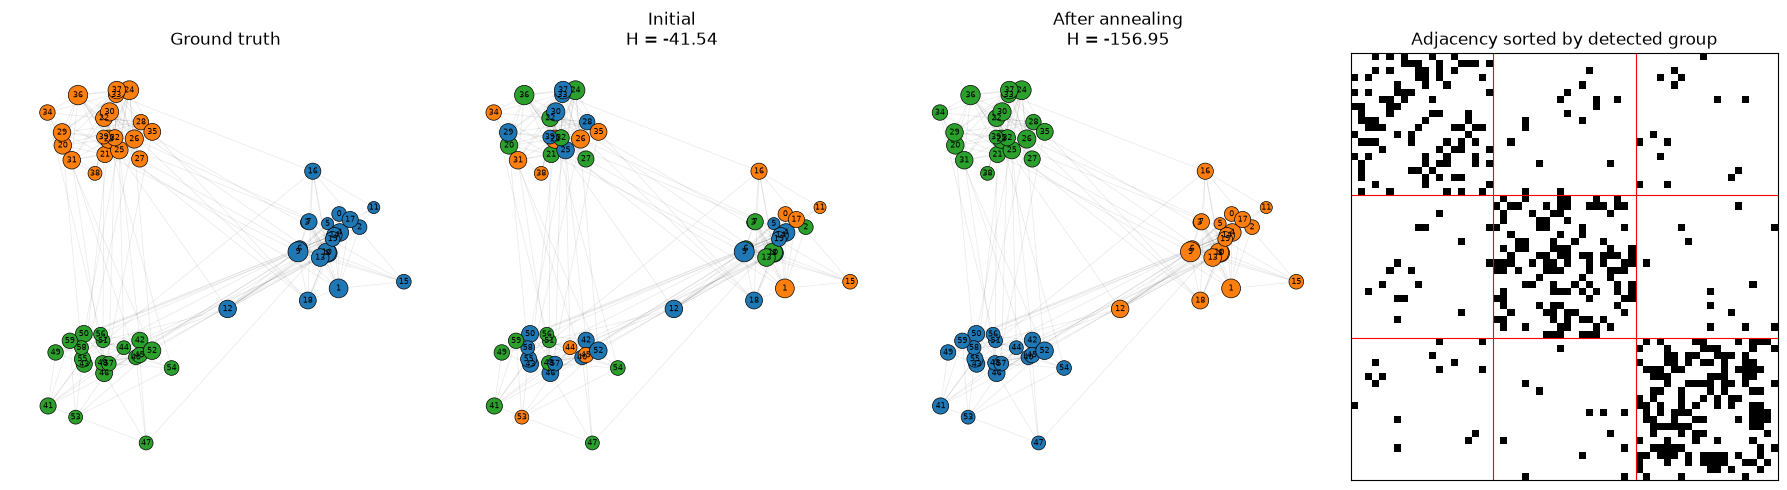

In [38]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


# ============================================================
# Plotting functions
# ============================================================

def draw_partition(G, sigma, pos=None, ax=None, title=None, cmap="tab10"):
    """Draw G with nodes coloured by community/state sigma."""
    
    ax = ax or plt.gca()
    sigma = np.asarray(sigma)

    if pos is None:
        pos = nx.spring_layout(G, seed=1)

    deg = np.array([d for _, d in G.degree()])

    nx.draw_networkx_edges(
        G, pos,
        ax=ax,
        alpha=0.08,
        width=0.6
    )

    nx.draw_networkx_nodes(
        G, pos,
        ax=ax,
        node_color=sigma,
        cmap=plt.get_cmap(cmap),
        vmin=0,
        vmax=max(9, sigma.max()),
        node_size=40 + 12 * deg,
        edgecolors="k",
        linewidths=0.5
    )

    nx.draw_networkx_labels(
        G, pos,
        ax=ax,
        font_size=6
    )

    ax.set_title(title)
    ax.set_axis_off()


def plot_adjacency_sorted(A, sigma, ax=None,
                          title="Adjacency, sorted by detected group"):
    """Plot adjacency matrix with nodes ordered by community."""
    
    ax = ax or plt.gca()
    sigma = np.asarray(sigma)

    order = np.argsort(sigma, kind="stable")

    ax.imshow(
        A[np.ix_(order, order)],
        cmap="Greys",
        interpolation="nearest"
    )

    # Draw lines at community boundaries
    counts = np.bincount(sigma[order])
    bounds = np.cumsum(counts)[:-1] - 0.5

    for b in bounds:
        ax.axhline(b, color="red", lw=0.8)
        ax.axvline(b, color="red", lw=0.8)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def community_layout(G, sigma):
    """
    Place each community around a separate point.

    This uses the known/planted communities only to make the
    visualisation clearer; the community-detection algorithm
    does not use this layout.
    """

    sigma = np.asarray(sigma)
    communities = np.unique(sigma)

    # Centres arranged around a circle
    centres = np.array([
        [
            np.cos(2 * np.pi * k / len(communities)),
            np.sin(2 * np.pi * k / len(communities))
        ]
        for k in range(len(communities))
    ])

    pos = {}
    rng = np.random.default_rng(1)

    for k, community in enumerate(communities):

        nodes = np.where(sigma == community)[0]

        for node in nodes:
            pos[node] = (
                centres[k]
                + 0.25 * rng.normal(size=2)
            )

    return pos


# ============================================================
# Generate a graph with planted communities
# ============================================================

sizes = [20, 20, 20]

p_in = 0.35
p_out = 0.03

# Connection probability matrix
P_sbm = np.full((3, 3), p_out)
np.fill_diagonal(P_sbm, p_in)

G = nx.stochastic_block_model(
    sizes,
    P_sbm,
    seed=1
)

A = nx.to_numpy_array(G)

# Known ground-truth communities
sigma_true = np.repeat(
    np.arange(3),
    sizes
)


# ============================================================
# Initial random configuration
# ============================================================

q = 3

rng = np.random.default_rng(1)

sigma0 = rng.integers(
    q,
    size=len(A)
)

sigma = sigma0.copy()


# ============================================================
# Coupling matrix
# ============================================================

J = A - P_func(A)


# ============================================================
# Simulated annealing
# ============================================================

for beta in [0.5, 1, 2, 4, 8]:

    for _ in range(50):

        heatbath_sweep(
            J,
            sigma,
            q,
            beta,
            rng
        )


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1, 4,
    figsize=(18, 5)
)


# Use the ground-truth communities only to construct
# a visually clear layout.
pos = community_layout(
    G,
    sigma_true
)


# ---- Ground truth ----

draw_partition(
    G,
    sigma_true,
    pos,
    axes[0],
    "Ground truth"
)


# ---- Initial configuration ----

draw_partition(
    G,
    sigma0,
    pos,
    axes[1],
    f"Initial\nH = {hamiltonian_cohesion(A, sigma0):.2f}"
)


# ---- Detected configuration ----

draw_partition(
    G,
    sigma,
    pos,
    axes[2],
    f"After annealing\nH = {hamiltonian_cohesion(A, sigma):.2f}"
)


# ---- Adjacency matrix ----

plot_adjacency_sorted(
    A,
    sigma,
    axes[3],
    "Adjacency sorted by detected group"
)


plt.tight_layout()
plt.show()